## Classification using MobileNetV3 Pre-trained model

1. Select a pre-trained model and specify the input size required by the model.
1. Load a test image and resize it to the appropriate size based on the selected model.
1. Pre-process the input image(s) using a dedicated pre-processing function that is accessible in the model, `preprocess_input()`.
1. Call the model's `predict()` method to generate predictions.
1. De-code the predictions using a dedicated post-processing function that is accessible in the model, `decode_predictions()`.

In [1]:
import numpy as np
import tensorflow as tf
import keras
from keras.preprocessing import image
import matplotlib.pyplot as plt

### Load and resize input

(np.float64(-0.5), np.float64(639.5), np.float64(955.5), np.float64(-0.5))

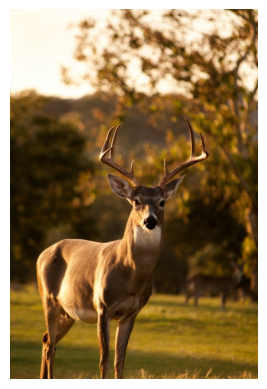

In [2]:
# IMG_PATH = "./dog-husky.jpg"
# IMG_PATH = "./tiger.jpg"
IMG_PATH = "./deer.jpg"
img = plt.imread(IMG_PATH)

plt.imshow(img)
plt.axis("off")

In [3]:
def loadPreprocessImage(imgPath, imgShape):
    imgBytes = tf.io.read_file(imgPath)

    # Decode the image from bytes format to tensor
    img = tf.image.decode_image(imgBytes, channels=imgShape[2])

    # Resize the image to the target size
    img = tf.image.resize(img, imgShape[:2])

    # Convert the single into a batch of 1, since batch is the input to the model
    img = tf.expand_dims(img, axis=0)

    return img

### Load the pre-trained model

In [4]:
IMG_SHAPE = (224, 224, 3)
MODEL_FAMILY = "mobilenet_v3"
MODEL_NAME = "MobileNetV3Small"

In [5]:
def loadPretrainedModel(inputShape, modelName):
    # Model will be loaded using the `imagenet` weights
    return getattr(keras.applications, modelName)(
        input_shape=inputShape, weights="imagenet"
    )

### Generate Predictions

**Pre-process step**: Before the image/batch of images can be passed as input for the model, the input should be pre-processed. Each model available in `tf.keras.applications` has a dedicated pre-processing function called `preprocess_input()`. This function is available in each model family's namespace.

**Generate Predictions**: Takes the pre-processed input and generates raw predictions. 

**Post-process step**: The raw predictions are be decoded into human-readable format and the top `k` predictions are returned by calling `decode_predictions()` function. This post-processing function is available in each model family's namespace. 

In [6]:
def generatePredictions(input, modelFamily, model, topK=5):
    # Pre-process the input
    preProcessedInput = getattr(keras.applications, modelFamily).preprocess_input(input)

    # Generate raw predictions
    rawPredictions = model.predict(preProcessedInput)

    # Post-process the predictions
    postProcessedPredictions = getattr(
        keras.applications, modelFamily
    ).decode_predictions(rawPredictions, top=topK)

    # Print the top predictions
    print("Predictions: ")
    for prediction in postProcessedPredictions[0]:
        print(f"Class: {prediction[1]} Score: {prediction[2]*100:.3f}")

In [8]:
### Perform Inference Using Pre-trained Model
input = loadPreprocessImage(IMG_PATH, IMG_SHAPE)
model = loadPretrainedModel(IMG_SHAPE, MODEL_NAME)
generatePredictions(input, MODEL_FAMILY, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Predictions: 
Class: impala Score: 28.751
Class: gazelle Score: 23.184
Class: ibex Score: 20.862
Class: hartebeest Score: 4.247
Class: bighorn Score: 0.826
